In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train (1).csv


In [ ]:
rm -rf ~/.cache/matplotlib/*

In [ ]:
#폰트 깨짐 방지 코드

!apt-get -qq install fonts-nanum

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy import stats

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fontprop = fm.FontProperties(fname=font_path)
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/matplotlibrc
/usr/local/lib/python3.12/dist-packages/matplotlib/__init__.py
['NanumGothic']


Text(0.3, 0.3, '한글')

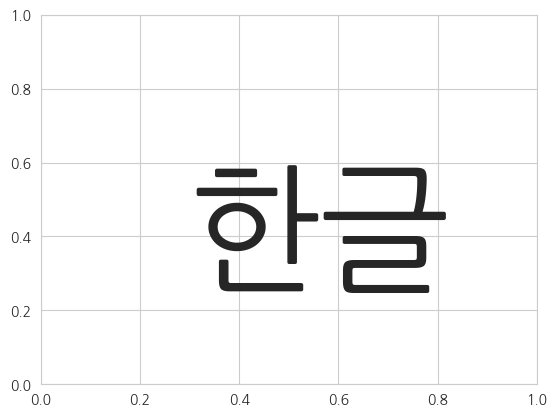

In [ ]:
import matplotlib as mpl
from matplotlib import font_manager as fm
from matplotlib import rc

# 설정 파일 위치 확인
print(mpl.matplotlib_fname())
print(mpl.__file__)

# Jupyter Notebook 로드 시 같이 올라온 font 목록 확인
[f.fname for f in fm.fontManager.ttflist]	# NanumGothic.ttf 목록에서 확인 완료!!!

# NanumGothic 설정 확인
plt.rcParams['font.family'] = 'NanumGothic'
print(plt.rcParams['font.family'])		# NanumGothic 설정 제대로 먹힌 것을 확인!!!

# 마이너스(-)가 '□'로 깨지는 것을 방지하기 위하여 설정!!!
mpl.rcParams['axes.unicode_minus'] = False

# matplotlib 차트에 한글이 제대로 표시되는지 확인
plt.text(0.3, 0.3, '한글', size = 100)

## **1. 데이터 개요**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("train.csv")

# 상위 데이터 확인
df.head()

,시점,품목명,품종명,거래단위,등급,평년 평균가격(원),평균가격(원)
0,201801상순,건고추,화건,30 kg,상품,381666.666667,590000.0
1,201801중순,건고추,화건,30 kg,상품,380809.666667,590000.0
2,201801하순,건고추,화건,30 kg,상품,380000.000000,590000.0
3,201802상순,건고추,화건,30 kg,상품,380000.000000,590000.0
4,201802중순,건고추,화건,30 kg,상품,376666.666667,590000.0


In [ ]:
import pandas as pd

df = pd.read_csv("train.csv")

target_condition = (
    ((df["품목명"] == "건고추") & (df["품종명"] == "화건") & (df["거래단위"] == "30 kg") & (df["등급"] == "상품")) |
    ((df["품목명"] == "사과") & (df["품종명"].isin(["홍로","후지"])) & (df["거래단위"] == "10 개") & (df["등급"] == "상품")) |
    ((df["품목명"] == "감자") & (df["품종명"] == "감자 수미") & (df["거래단위"] == "20키로상자") & (df["등급"] == "상")) |
    ((df["품목명"] == "배") & (df["품종명"] == "신고") & (df["거래단위"] == "10 개") & (df["등급"] == "상품")) |
    ((df["품목명"] == "깐마늘(국산)") & (df["품종명"] == "깐마늘(국산)") & (df["거래단위"] == "20 kg") & (df["등급"] == "상품")) |
    ((df["품목명"] == "무") & (df["품종명"] == "무") & (df["거래단위"] == "20키로상자") & (df["등급"] == "상")) |
    ((df["품목명"] == "상추") & (df["품종명"] == "청") & (df["거래단위"] == "100 g") & (df["등급"] == "상품")) |
    ((df["품목명"] == "배추") & (df["품종명"] == "배추") & (df["거래단위"] == "10키로망대") & (df["등급"] == "상")) |
    ((df["품목명"] == "양파") & (df["품종명"] == "양파") & (df["거래단위"] == "1키로") & (df["등급"] == "상")) |
    ((df["품목명"] == "대파") & (df["품종명"] == "대파(일반)") & (df["거래단위"] == "1키로단") & (df["등급"] == "상"))
)

df_target = df[target_condition].copy()

print(df.shape)
print(df_target.shape)

(29376, 7)
(1440, 7)


In [ ]:
df = df_target.copy()

In [ ]:
#시점 데이터 확인 (나중에 날짜 변환 전처리 필요)

df['시점'].head(20)

,시점
0,201801상순
1,201801중순
2,201801하순
3,201802상순
4,201802중순
5,201802하순
6,201803상순
7,201803중순
8,201803하순
9,201804상순


## **2. 품목별 가격 분포 분석**

In [ ]:
# 품목별 평균 가격, 중앙값, 최소값, 최대값, 가격 범위 요약표

# 품목별 가격 요약 통계
item_price_summary = (
    df.groupby("품목명")["평균가격(원)"]
    .agg(
        평균가격="mean",
        중앙값="median",
        최저가격="min",
        최고가격="max",
        표준편차="std"
    )
    .round(2)
)

# 가격 범위 변수 추가
item_price_summary["가격범위"] = (
    item_price_summary["최고가격"] - item_price_summary["최저가격"]
).round(2)


item_price_summary = item_price_summary.sort_values(by="평균가격", ascending=False)

print("품목별 가격 요약표")
display(item_price_summary)


품목별 가격 요약표


,평균가격,중앙값,최저가격,최고가격,표준편차,가격범위
품목명,,,,,,
건고추,597980.80,583734.00,396000.00,905650.00,130256.49,509650.00
깐마늘(국산),122036.21,124007.25,74500.00,169100.00,27518.05,94600.00
감자,36446.47,32385.95,16343.60,115127.75,16835.70,98784.15
배,36352.69,35043.00,26699.00,53463.00,6741.39,26764.00
사과,24809.94,24734.75,17583.00,35339.00,4848.51,17756.00
무,12669.12,10746.32,5724.44,27820.60,5536.42,22096.16
배추,7847.13,7546.69,2466.11,25820.88,4118.28,23354.77
대파,1785.86,1501.93,698.44,5488.83,946.89,4790.39
상추,1062.30,943.00,623.00,2403.00,394.58,1780.00


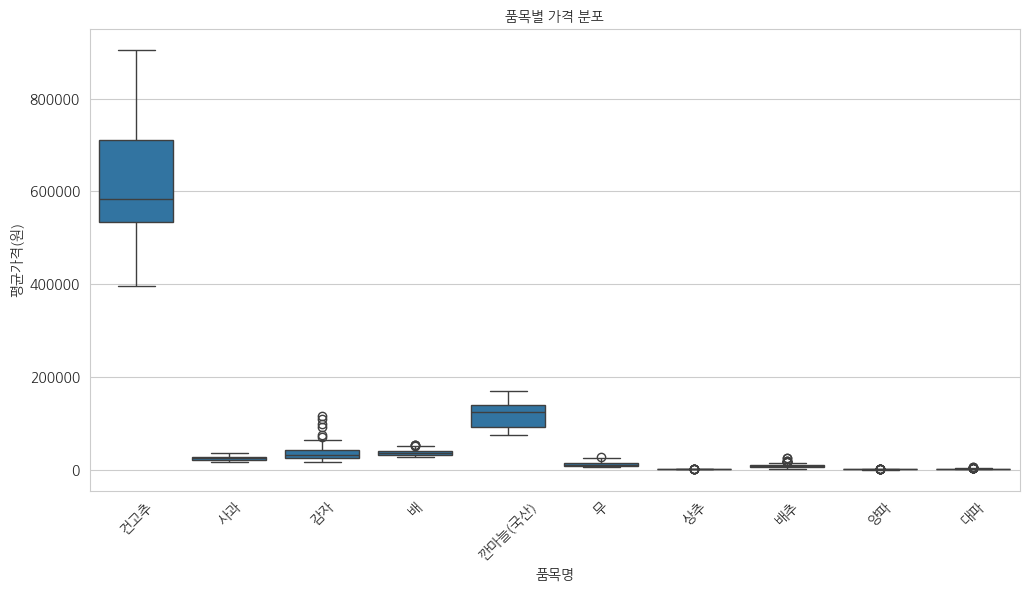

In [ ]:
# 품목별 가격 분포 전체
# ❤️

plt.figure(figsize=(12, 6))

ax = sns.boxplot(
    data=df,
    x="품목명",
    y="평균가격(원)"
)

plt.title("품목별 가격 분포", fontproperties=fontprop)
plt.xlabel("품목명", fontproperties=fontprop)
plt.ylabel("평균가격(원)", fontproperties=fontprop)

for label in ax.get_xticklabels():
    label.set_fontproperties(fontprop)
    label.set_rotation(45)

plt.show()

## **3. 시계열 가격 변화 분석**

In [ ]:
# 시점 컬럼 날짜형으로 변환

df_time = df.copy()
def convert_period_to_date(period):
    period = str(period)

    year_month = period[:6]   # 예: 201801
    suffix = period[6:]       # 예: 상순 / 중순 / 하순

    if suffix == "상순":
        day = "10"
    elif suffix == "중순":
        day = "20"
    elif suffix == "하순":
        day = "30"
    else:
        day = "01"

    return pd.to_datetime(year_month + day, format="%Y%m%d", errors="coerce")

df_time["date"] = df_time["시점"].apply(convert_period_to_date)
df_time[["시점", "date"]].head()

,시점,date
0,201801상순,2018-01-10
1,201801중순,2018-01-20
2,201801하순,2018-01-30
3,201802상순,2018-02-10
4,201802중순,2018-02-20


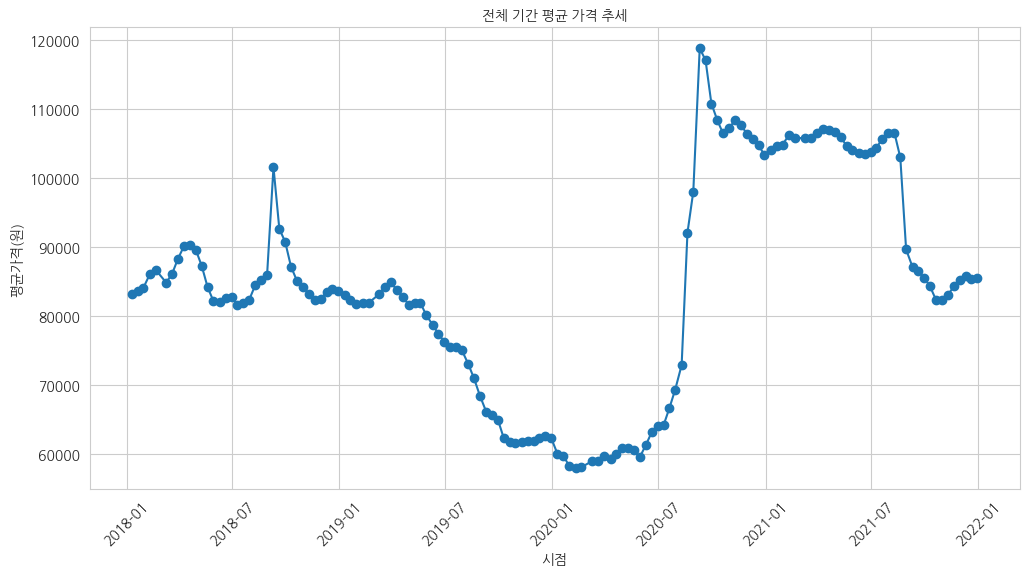

In [ ]:
# 전체 기간 평균 가격 추세

overall_trend = df_time.groupby("date")["평균가격(원)"].mean().reset_index()

plt.figure(figsize=(12, 6))

plt.plot(
    overall_trend["date"],
    overall_trend["평균가격(원)"],
    marker="o"
)

plt.title("전체 기간 평균 가격 추세", fontproperties=fontprop)
plt.xlabel("시점", fontproperties=fontprop)
plt.ylabel("평균가격(원)", fontproperties=fontprop)

plt.xticks(rotation=45)
plt.show()

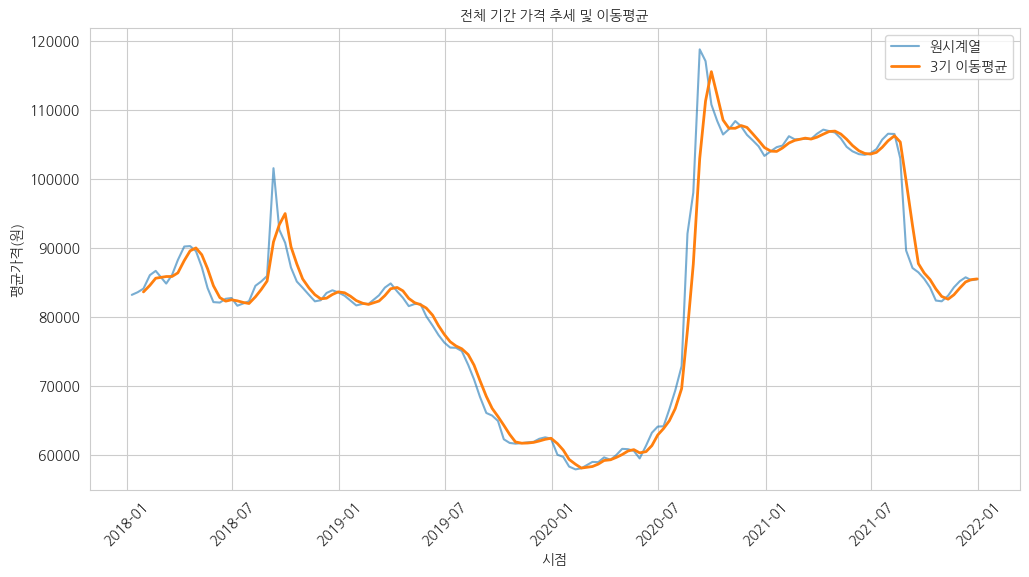

In [ ]:
# 이동평균으로 장기 추세 확인

overall_trend["이동평균_3"] = overall_trend["평균가격(원)"].rolling(window=3).mean()

plt.figure(figsize=(12, 6))

plt.plot(
    overall_trend["date"],
    overall_trend["평균가격(원)"],
    label="원시계열",
    alpha=0.6
)

plt.plot(
    overall_trend["date"],
    overall_trend["이동평균_3"],
    label="3기 이동평균",
    linewidth=2
)

plt.title("전체 기간 가격 추세 및 이동평균", fontproperties=fontprop)
plt.xlabel("시점", fontproperties=fontprop)
plt.ylabel("평균가격(원)", fontproperties=fontprop)

plt.xticks(rotation=45)
plt.legend(prop=fontprop)
plt.show()

,date,품목명,평균가격(원)
0,2018-01-10,감자,44170.285714
1,2018-01-10,건고추,590000.000000
2,2018-01-10,깐마늘(국산),130666.666667
3,2018-01-10,대파,1685.285714
4,2018-01-10,무,9283.571429


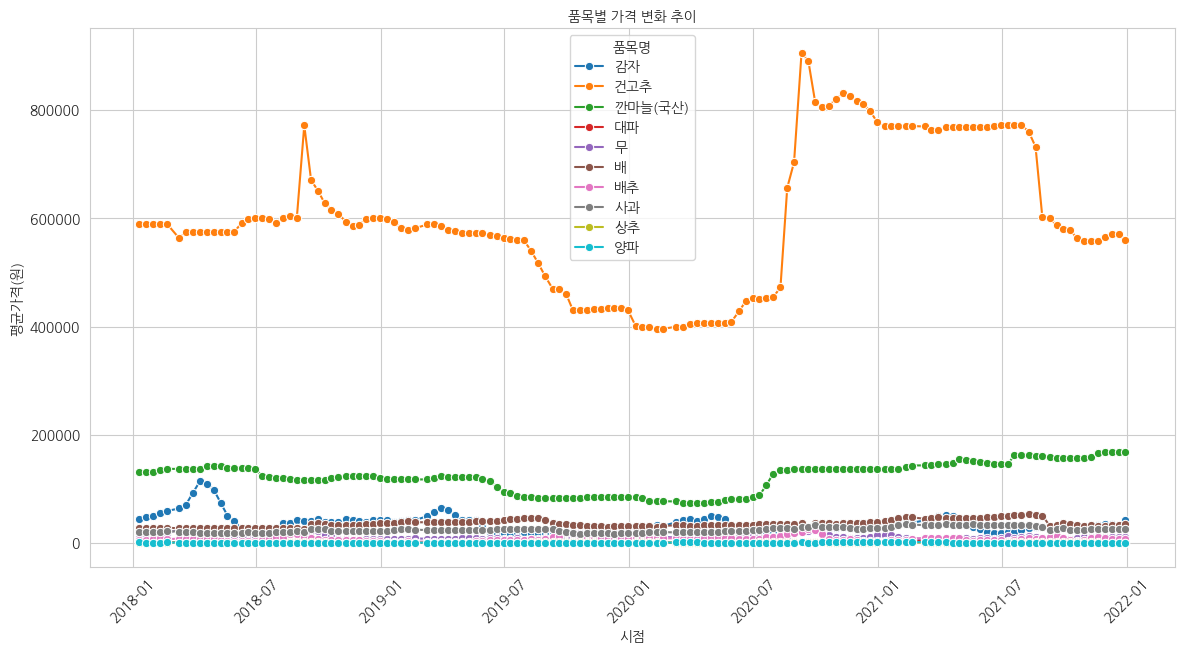

In [ ]:
# 품목별 가격 변화

item_trend = (
    df_time.groupby(["date", "품목명"])["평균가격(원)"]
    .mean()
    .reset_index()
)

display(item_trend.head())

plt.figure(figsize=(14, 7))

ax = sns.lineplot(
    data=item_trend,
    x="date",
    y="평균가격(원)",
    hue="품목명",
    marker="o"
)

plt.title("품목별 가격 변화 추이", fontproperties=fontprop)
plt.xlabel("시점", fontproperties=fontprop)
plt.ylabel("평균가격(원)", fontproperties=fontprop)

plt.xticks(rotation=45)

legend = plt.legend(title="품목명")
plt.setp(legend.get_texts(), fontproperties=fontprop)
plt.setp(legend.get_title(), fontproperties=fontprop)

plt.show()

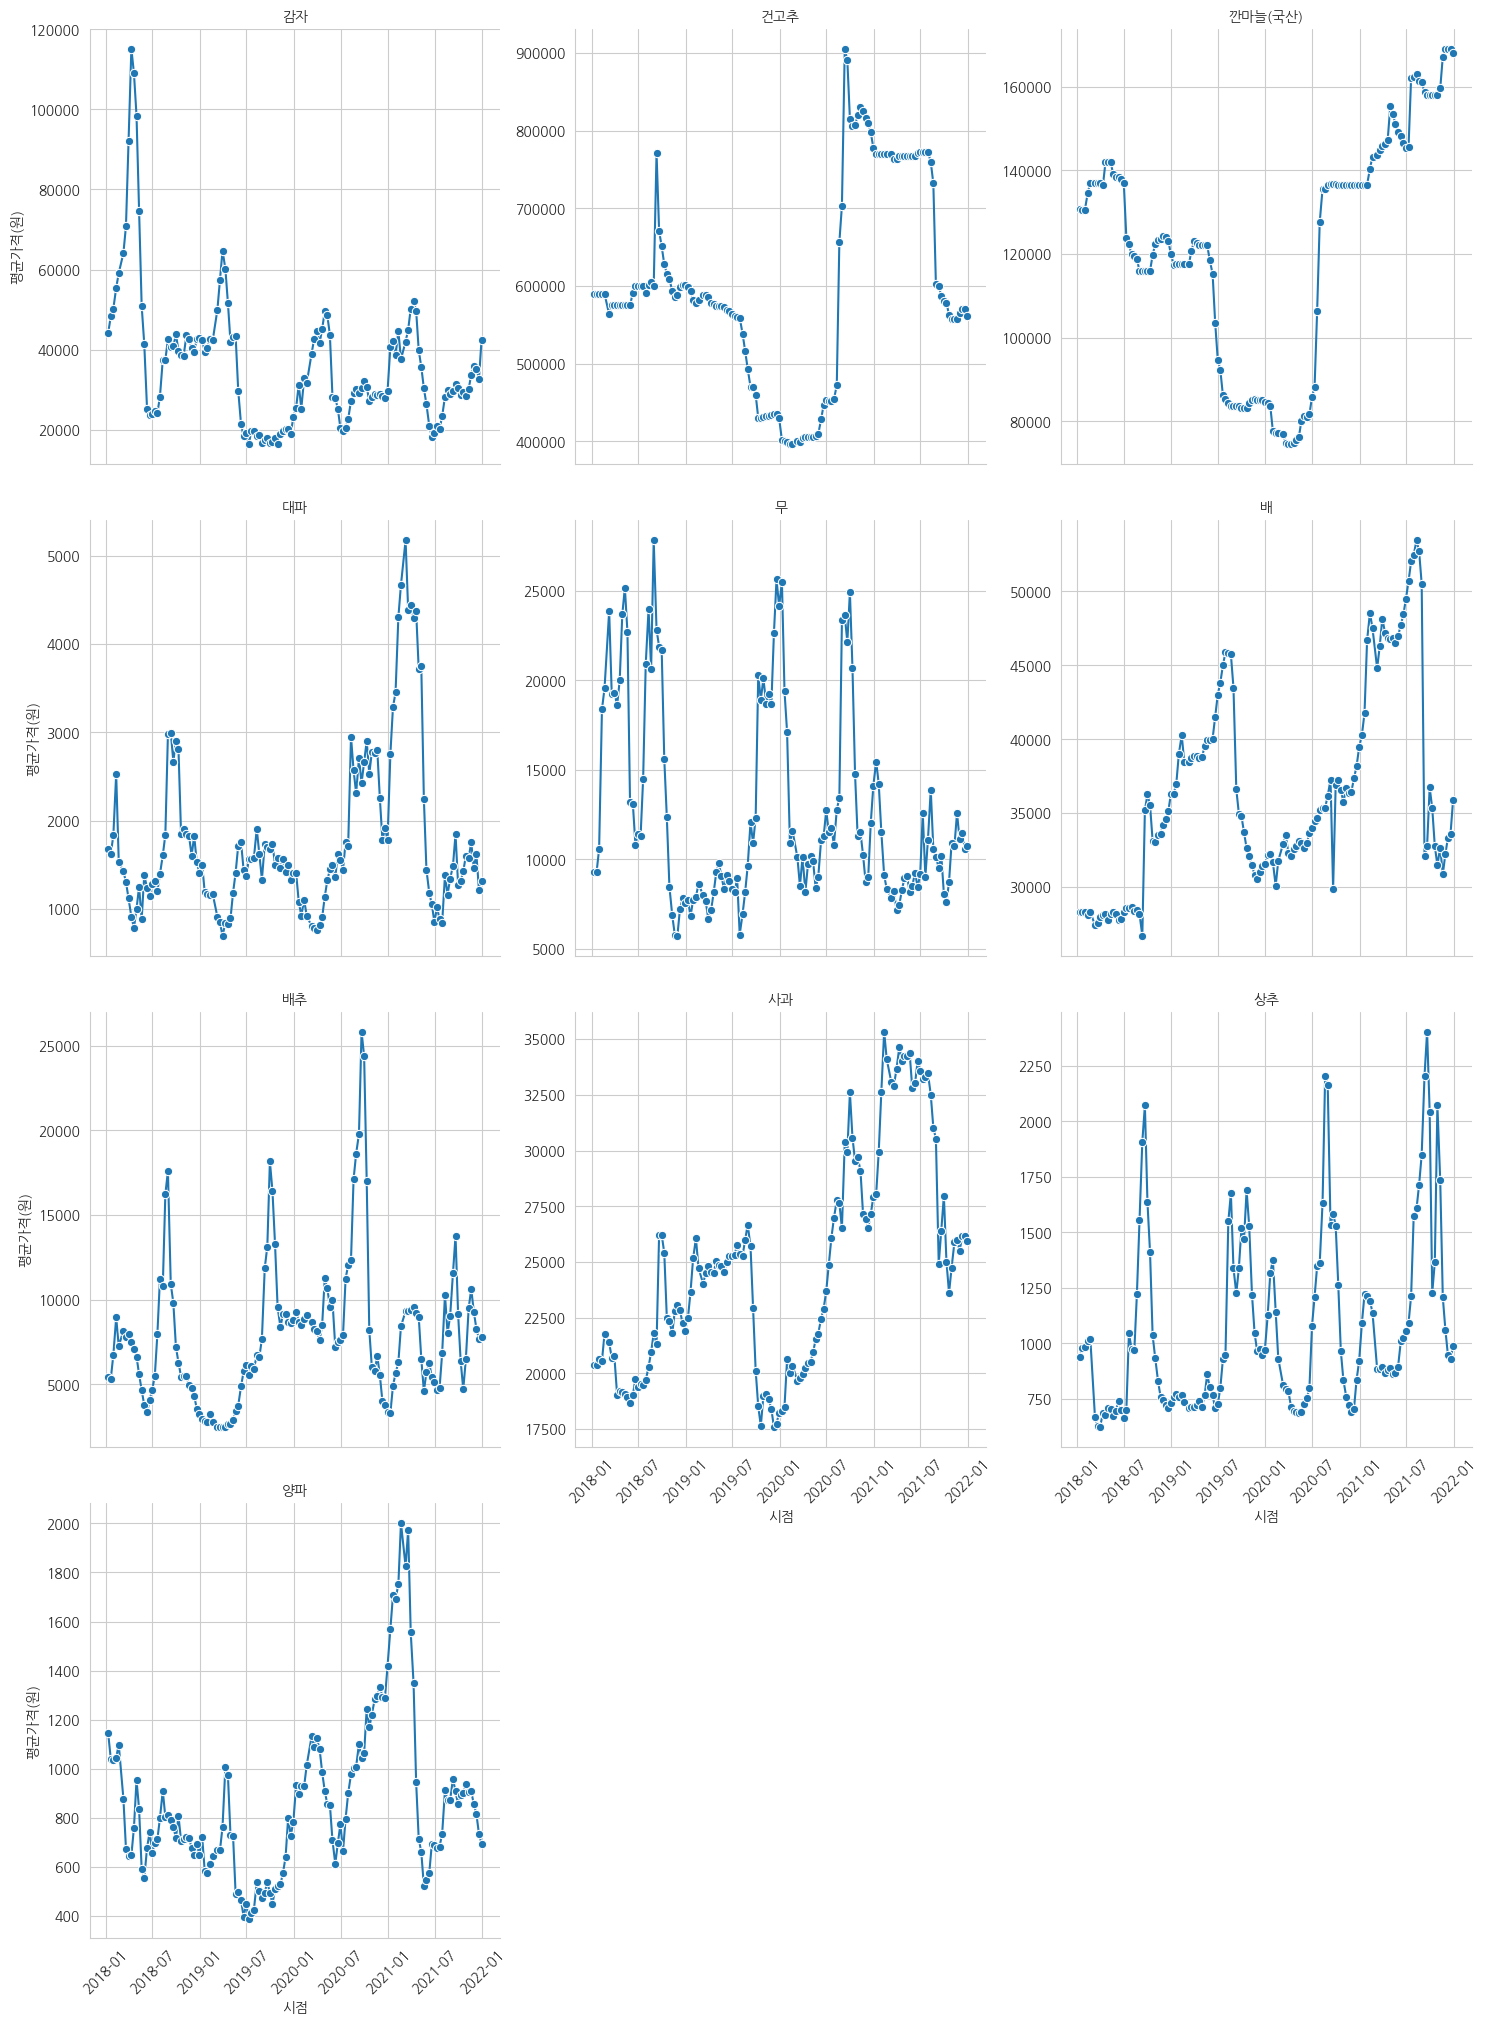

In [ ]:
g = sns.FacetGrid(
    item_trend,
    col="품목명",
    col_wrap=3,   # 한 줄에 3개 그래프
    height=5,
    sharey=False  # 품목마다 y축 다르게 (중요!)
)

g.map_dataframe(
    sns.lineplot,
    x="date",
    y="평균가격(원)",
    marker="o"
)

g.set_axis_labels("시점", "평균가격(원)")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45)

plt.show()

In [ ]:
# 급등 시기 확인

overall_trend = overall_trend.sort_values("date")
overall_trend["전시점대비증감률(%)"] = overall_trend["평균가격(원)"].pct_change() * 100

display(overall_trend.head())


# 급등/급락 상위 시점 확인

print("\n<급등 시기 TOP 10>")
display(
    overall_trend.sort_values("전시점대비증감률(%)", ascending=False)
    [["date", "평균가격(원)", "전시점대비증감률(%)"]]
    .head(10)
)

print("\n<급락 시기 TOP 10>")
display(
    overall_trend.sort_values("전시점대비증감률(%)", ascending=True)
    [["date", "평균가격(원)", "전시점대비증감률(%)"]]
    .head(10)
)

,date,평균가격(원),이동평균_3,전시점대비증감률(%)
0,2018-01-10,83198.309524,NaN,NaN
1,2018-01-20,83575.911111,NaN,0.453857
2,2018-01-30,84098.466667,83624.229101,0.625247
3,2018-02-10,86056.972222,84577.116667,2.328824
4,2018-02-20,86675.683333,85610.374074,0.718955



<급등 시기 TOP 10>


,date,평균가격(원),전시점대비증감률(%)
91,2020-08-20,92069.916667,26.335917
93,2020-09-10,118790.777778,21.176892
23,2018-09-10,101561.912500,18.190982
92,2020-08-30,98030.883333,6.474391
90,2020-08-10,72877.071429,5.123189
89,2020-07-30,69325.400000,4.038747
88,2020-07-20,66634.212500,3.886595
84,2020-06-10,61341.233333,3.125881
85,2020-06-20,63203.961111,3.036665
20,2018-08-10,84511.775000,2.721161



<급락 시기 TOP 10>


,date,평균가격(원),전시점대비증감률(%)
127,2021-08-30,89630.566667,-12.959493
24,2018-09-20,92631.077778,-8.793488
95,2020-09-30,110796.694444,-5.371597
61,2019-10-10,62260.544444,-4.092893
26,2018-10-10,87162.000000,-3.953105
70,2020-01-10,60016.285714,-3.735283
57,2019-08-30,68438.070000,-3.509296
12,2018-05-20,84173.675000,-3.507577
58,2019-09-10,66074.900000,-3.453005
126,2021-08-20,102975.694444,-3.330194


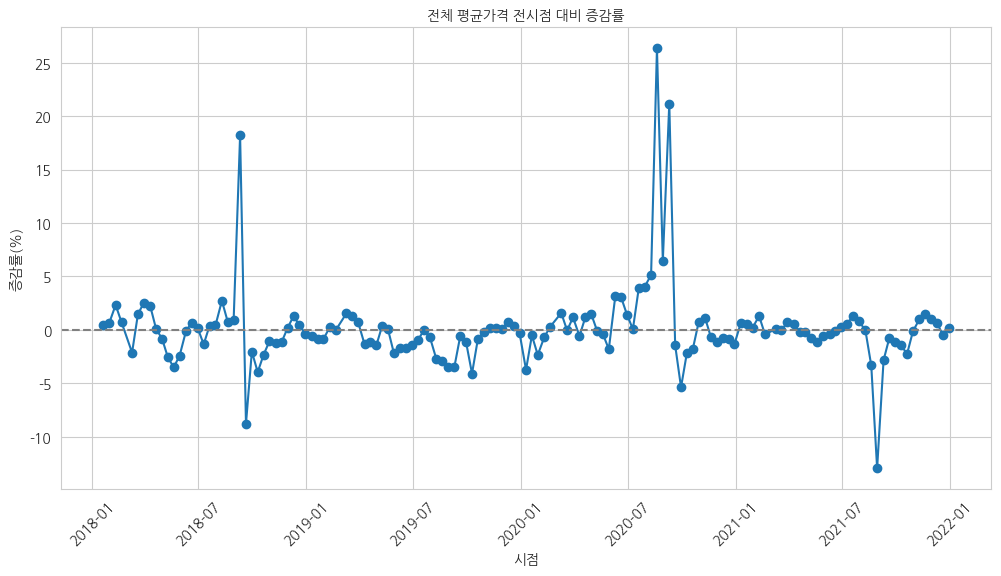

In [ ]:
# 전시점 대비 증감률 시각화

plt.figure(figsize=(12, 6))

plt.plot(
    overall_trend["date"],
    overall_trend["전시점대비증감률(%)"],
    marker="o"
)

plt.title("전체 평균가격 전시점 대비 증감률", fontproperties=fontprop)
plt.xlabel("시점", fontproperties=fontprop)
plt.ylabel("증감률(%)", fontproperties=fontprop)

plt.axhline(0, color="gray", linestyle="--")
plt.xticks(rotation=45)

plt.show()

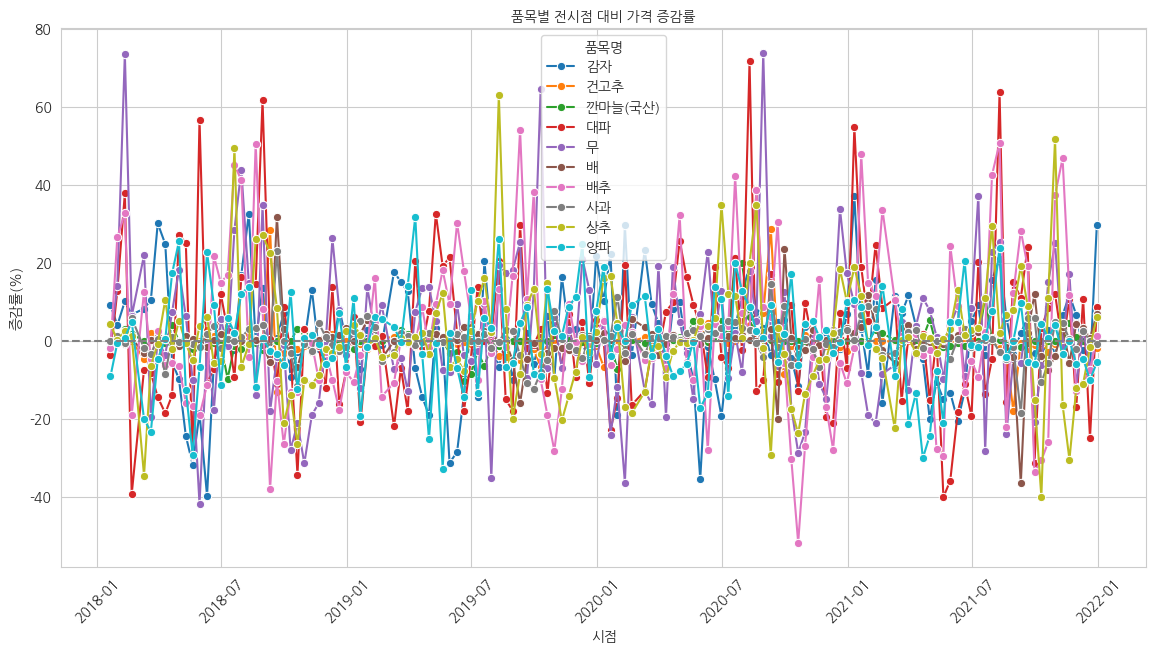

In [ ]:
# 품목별 전시점 대비 가격 증감률 시각화

item_trend = item_trend.sort_values(["품목명", "date"])
item_trend["전시점대비증감률(%)"] = (
    item_trend.groupby("품목명")["평균가격(원)"]
    .pct_change() * 100
)

plt.figure(figsize=(14, 7))

ax = sns.lineplot(
    data=item_trend,
    x="date",
    y="전시점대비증감률(%)",
    hue="품목명",
    marker="o"
)

plt.title("품목별 전시점 대비 가격 증감률", fontproperties=fontprop)
plt.xlabel("시점", fontproperties=fontprop)
plt.ylabel("증감률(%)", fontproperties=fontprop)

plt.axhline(0, color="gray", linestyle="--")
plt.xticks(rotation=45)

legend = plt.legend(title="품목명")
plt.setp(legend.get_texts(), fontproperties=fontprop)
plt.setp(legend.get_title(), fontproperties=fontprop)

plt.show()

## **4. 계절성 분석**



In [ ]:
#

df_time["month"] = df_time["date"].dt.month

display(df_time[["date", "month"]].head())

,date,month
0,2018-01-10,1.0
1,2018-01-20,1.0
2,2018-01-30,1.0
3,2018-02-10,2.0
4,2018-02-20,2.0


,month,평균가격(원)
0,1.0,82457.613122
1,2.0,83050.872986
2,3.0,83926.583819
3,4.0,84918.071644
4,5.0,82737.736389
5,6.0,81608.400000
6,7.0,82387.465046
7,8.0,85840.759497
8,9.0,90615.234008
9,10.0,84426.284977


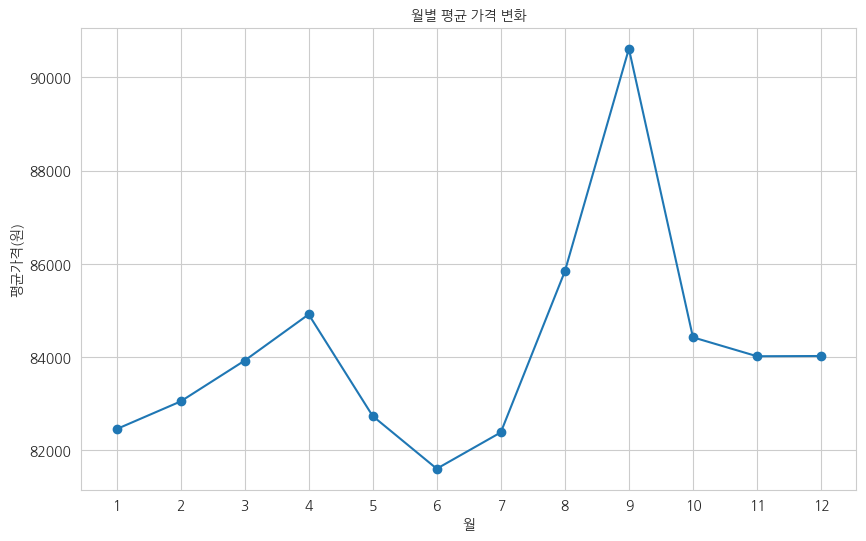

In [ ]:
# 월별 평균 가격 변화

monthly_price = (
    df_time.groupby("month")["평균가격(원)"]
    .mean()
    .reset_index()
)

display(monthly_price)

plt.figure(figsize=(10, 6))

plt.plot(
    monthly_price["month"],
    monthly_price["평균가격(원)"],
    marker="o"
)

plt.title("월별 평균 가격 변화", fontproperties=fontprop)
plt.xlabel("월", fontproperties=fontprop)
plt.ylabel("평균가격(원)", fontproperties=fontprop)

plt.xticks(range(1,13))

plt.show()

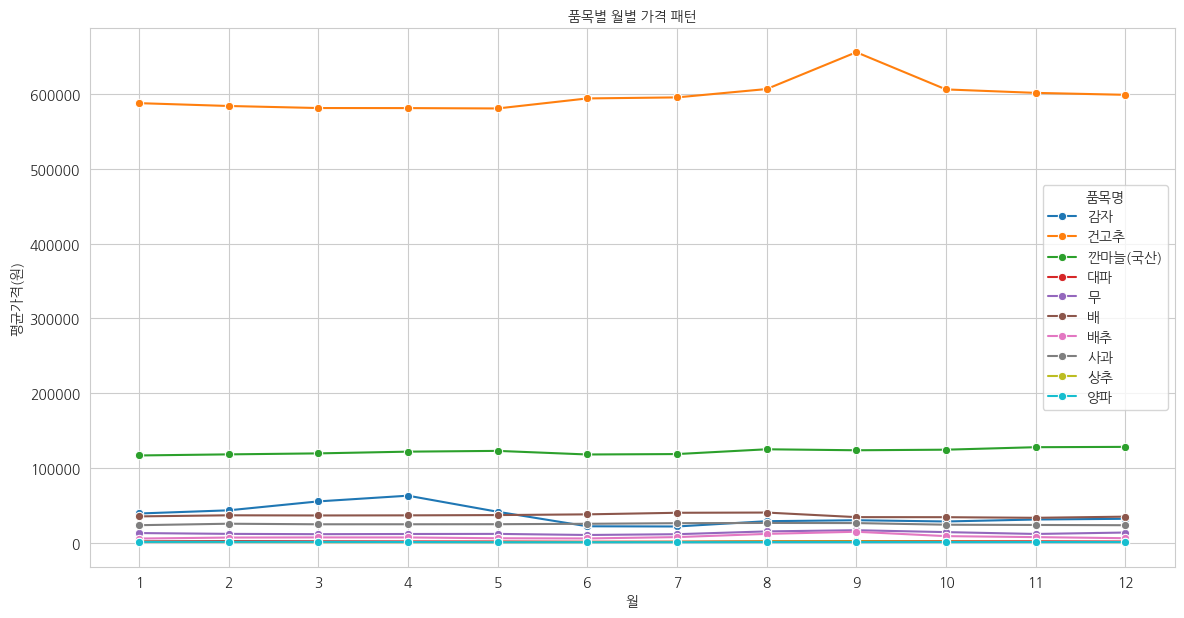

In [ ]:
# 품목별 월별 가격 패턴

monthly_item_price = (
    df_time.groupby(["month", "품목명"])["평균가격(원)"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 7))

ax = sns.lineplot(
    data=monthly_item_price,
    x="month",
    y="평균가격(원)",
    hue="품목명",
    marker="o"
)

plt.title("품목별 월별 가격 패턴", fontproperties=fontprop)
plt.xlabel("월", fontproperties=fontprop)
plt.ylabel("평균가격(원)", fontproperties=fontprop)

plt.xticks(range(1,13))

legend = plt.legend(title="품목명")
plt.setp(legend.get_texts(), fontproperties=fontprop)
plt.setp(legend.get_title(), fontproperties=fontprop)

plt.show()

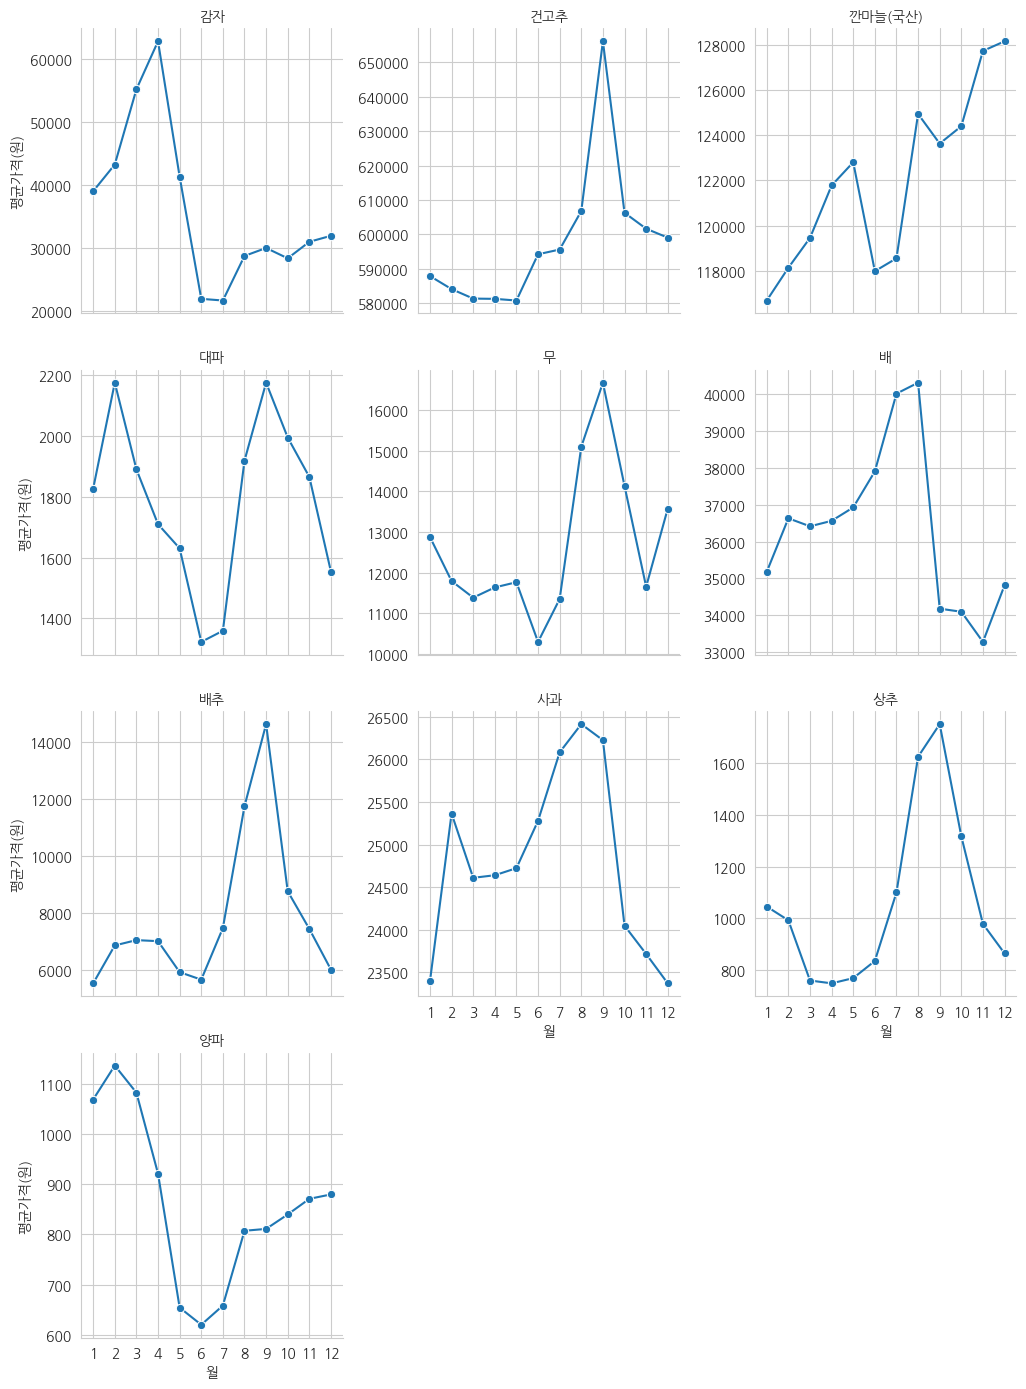

In [ ]:
# 품목별 월별 평균 가격 계산
monthly_item_price = (
    df_time.groupby(["품목명", "month"])["평균가격(원)"]
    .mean()
    .reset_index()
)

# 품목별 그래프
g = sns.FacetGrid(
    monthly_item_price,
    col="품목명",
    col_wrap=3,     # 한 줄에 3개 그래프
    height=3.5,
    sharey=False    # 품목마다 y축 다르게
)

g.map_dataframe(
    sns.lineplot,
    x="month",
    y="평균가격(원)",
    marker="o"
)

g.set_axis_labels("월", "평균가격(원)")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.set_xticks(range(1,13))
    ax.tick_params(axis="x", rotation=0)

plt.show()

## **5. 평년가격 vs. 실제가격 비교**


In [ ]:
df_time = df.copy()

In [ ]:
# 가격차이 변수 생성
df_time = df.copy()

# 가격차이 변수 생성
df_time["가격차이"] = df_time["평균가격(원)"] - df_time["평년 평균가격(원)"]

# 가격차이 비율
df_time["가격차이율(%)"] = (
    df_time["가격차이"] / df_time["평년 평균가격(원)"]
) * 100

display(df_time.head())

,시점,품목명,품종명,거래단위,등급,평년 평균가격(원),평균가격(원),가격차이,가격차이율(%)
0,201801상순,건고추,화건,30 kg,상품,381666.666667,590000.0,208333.333333,54.585153
1,201801중순,건고추,화건,30 kg,상품,380809.666667,590000.0,209190.333333,54.933042
2,201801하순,건고추,화건,30 kg,상품,380000.000000,590000.0,210000.000000,55.263158
3,201802상순,건고추,화건,30 kg,상품,380000.000000,590000.0,210000.000000,55.263158
4,201802중순,건고추,화건,30 kg,상품,376666.666667,590000.0,213333.333333,56.637168


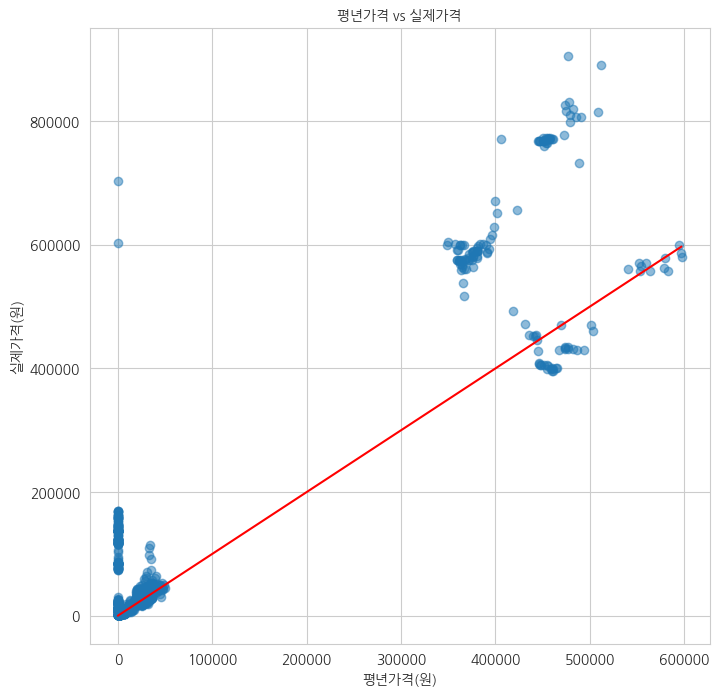

In [ ]:
# 평년가격 vs 실제가격 산점도

plt.figure(figsize=(8,8))

plt.scatter(
    df_time["평년 평균가격(원)"],
    df_time["평균가격(원)"],
    alpha=0.5
)

plt.plot(
    [df_time["평년 평균가격(원)"].min(), df_time["평년 평균가격(원)"].max()],
    [df_time["평년 평균가격(원)"].min(), df_time["평년 평균가격(원)"].max()],
    color="red"
)

plt.title("평년가격 vs 실제가격", fontproperties=fontprop)
plt.xlabel("평년가격(원)", fontproperties=fontprop)
plt.ylabel("실제가격(원)", fontproperties=fontprop)

plt.show()

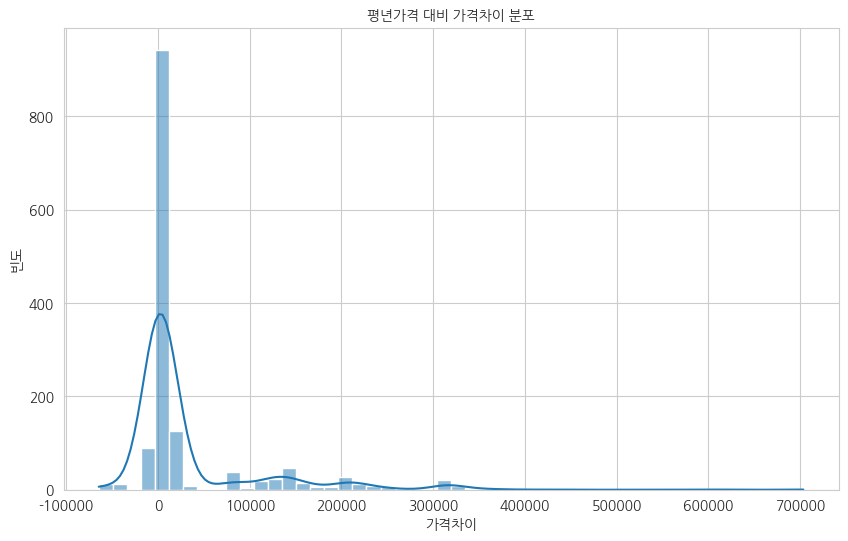

In [ ]:
# 가격차이 분포 분석
# ❤️

plt.figure(figsize=(10,6))

sns.histplot(
    df_time["가격차이"],
    bins=50,
    kde=True
)

plt.title("평년가격 대비 가격차이 분포", fontproperties=fontprop)
plt.xlabel("가격차이", fontproperties=fontprop)
plt.ylabel("빈도", fontproperties=fontprop)

plt.show()


## **6. 품종별 가격 분석**



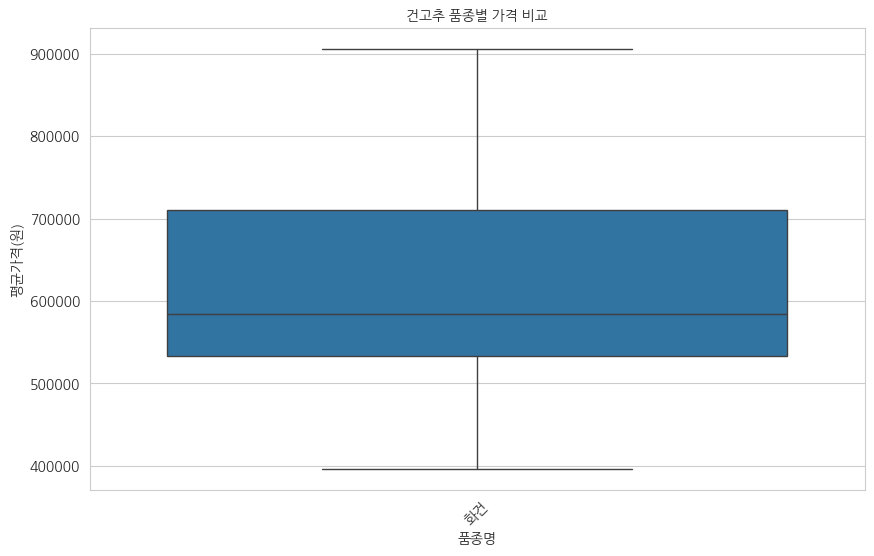

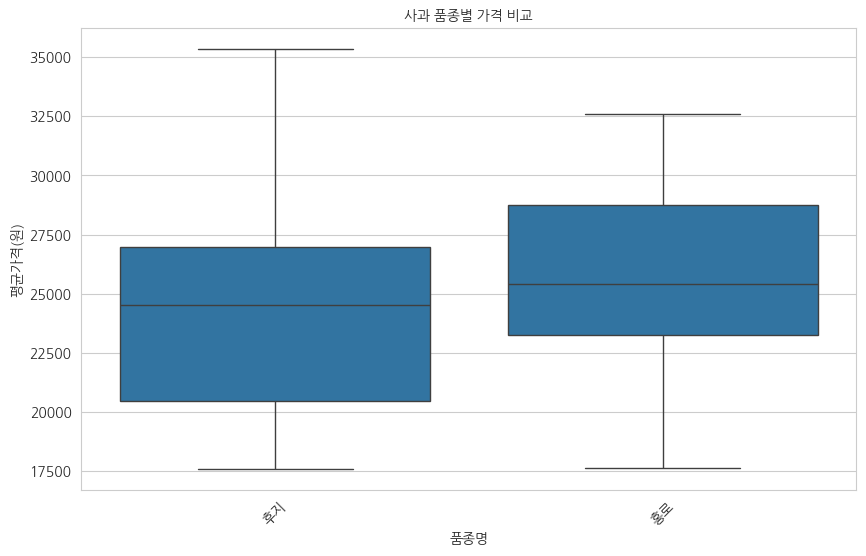

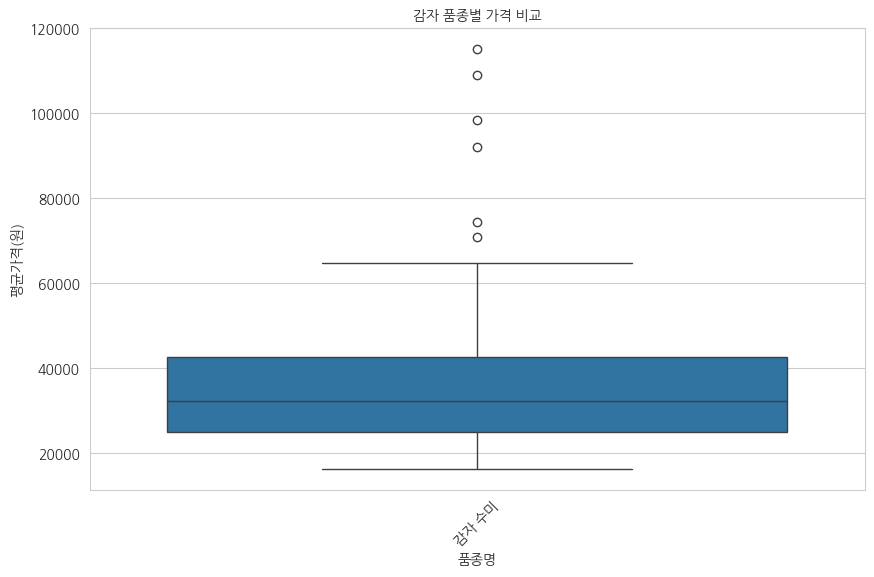

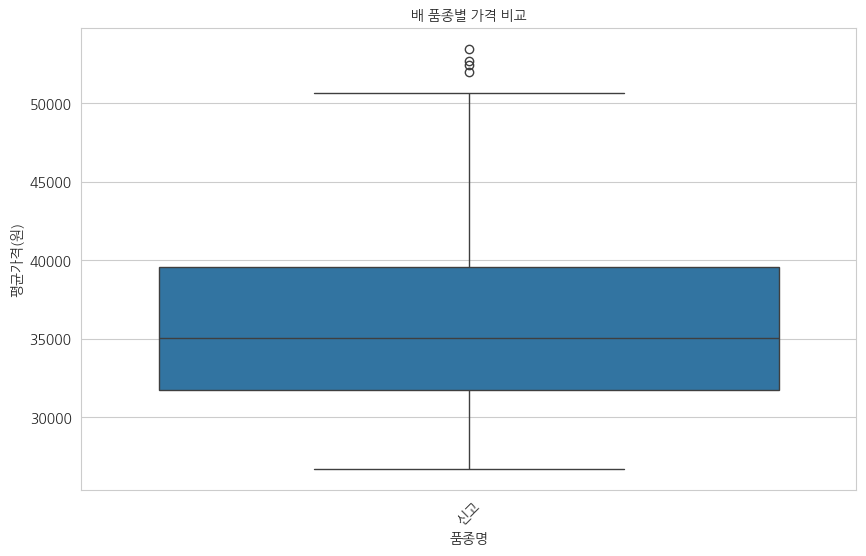

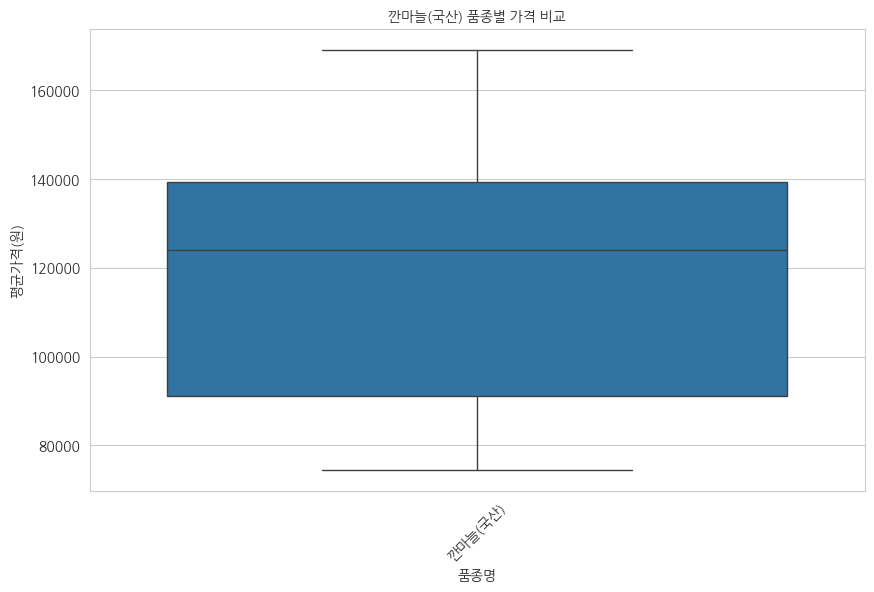

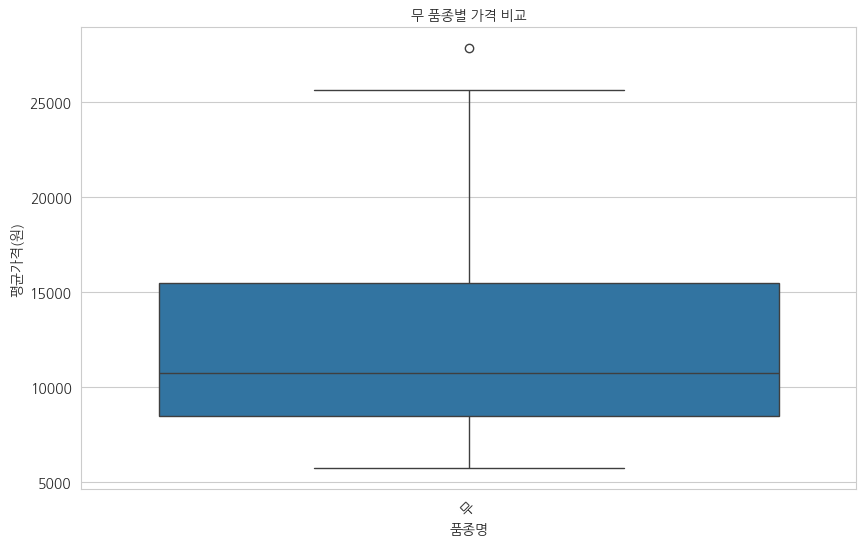

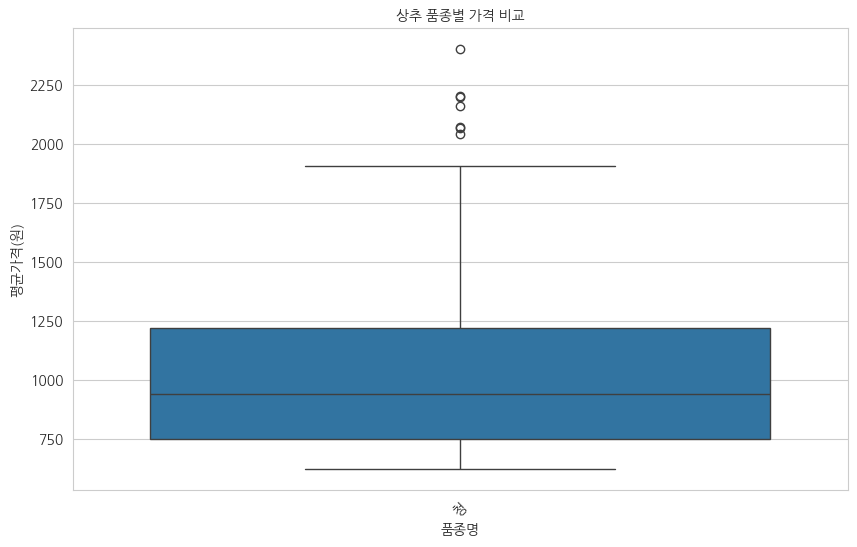

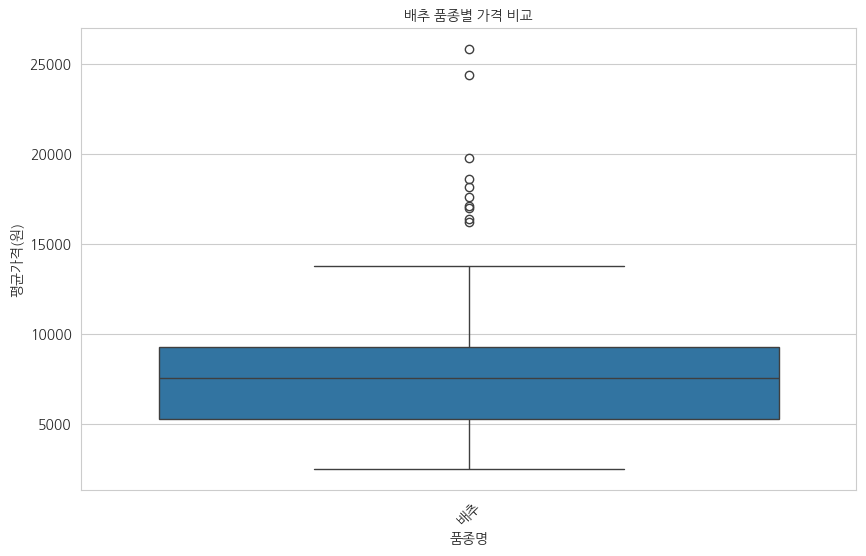

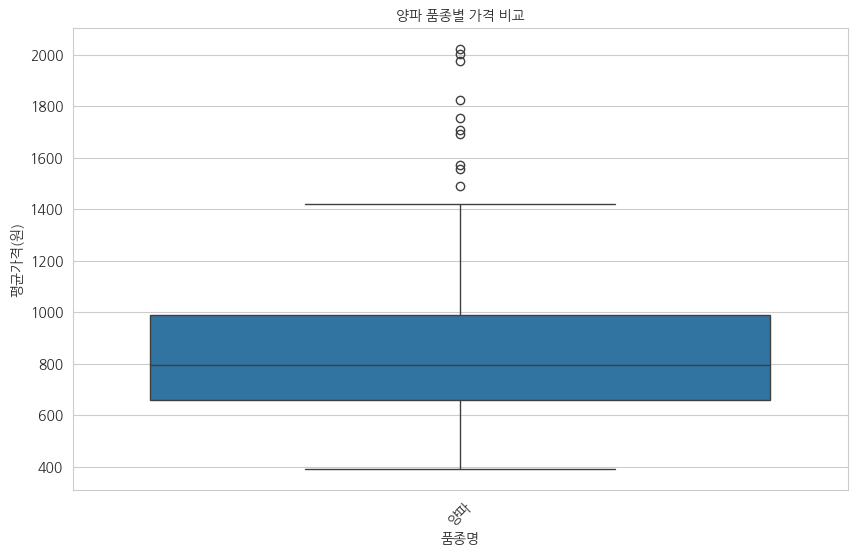

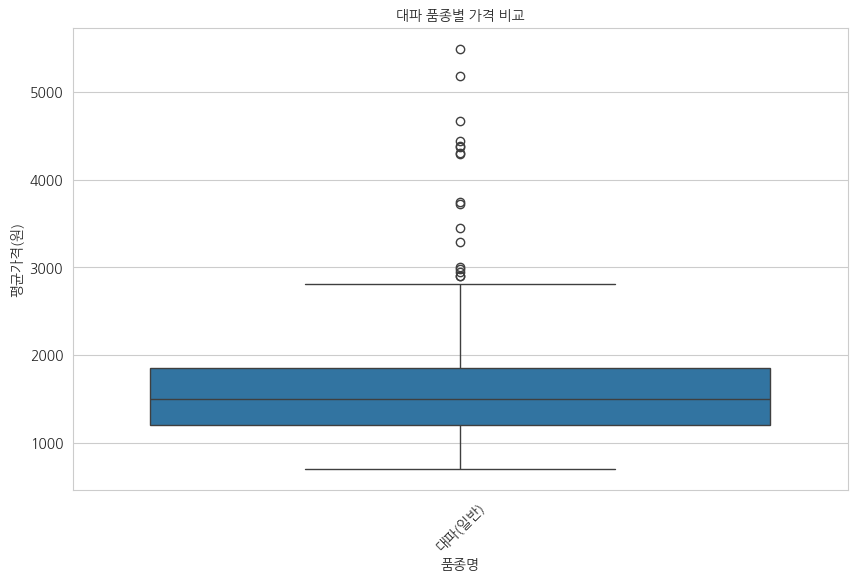

In [ ]:
# 같은 품목 내 품종 비교

items = df["품목명"].unique()

for item in items:

    item_variety = df[df["품목명"] == item]

    plt.figure(figsize=(10,6))

    ax = sns.boxplot(
        data=item_variety,
        x="품종명",
        y="평균가격(원)"
    )

    plt.title(f"{item} 품종별 가격 비교", fontproperties=fontprop)
    plt.xlabel("품종명", fontproperties=fontprop)
    plt.ylabel("평균가격(원)", fontproperties=fontprop)

    plt.xticks(rotation=45)

    for label in ax.get_xticklabels():
        label.set_fontproperties(fontprop)

    plt.show()



In [ ]:
import numpy as np
import pandas as pd

df_time = df.copy()

def get_soon(period):
    period = str(period)
    suffix = period[6:]
    if suffix == "상순":
        return 1
    elif suffix == "중순":
        return 2
    elif suffix == "하순":
        return 3
    return np.nan

def convert_period_to_date(period):
    period = str(period)

    year_month = period[:6]
    suffix = period[6:]

    if suffix == "상순":
        day = "10"
    elif suffix == "중순":
        day = "20"
    elif suffix == "하순":
        day = "30"
    else:
        day = "01"

    return pd.to_datetime(year_month + day, format="%Y%m%d", errors="coerce")

df_time["date"] = df_time["시점"].apply(convert_period_to_date)
df_time["month"] = df_time["date"].dt.month
df_time["soon"] = df_time["시점"].apply(get_soon)
df_time["month_soon"] = df_time["month"].astype(str) + "_" + df_time["soon"].astype(str)

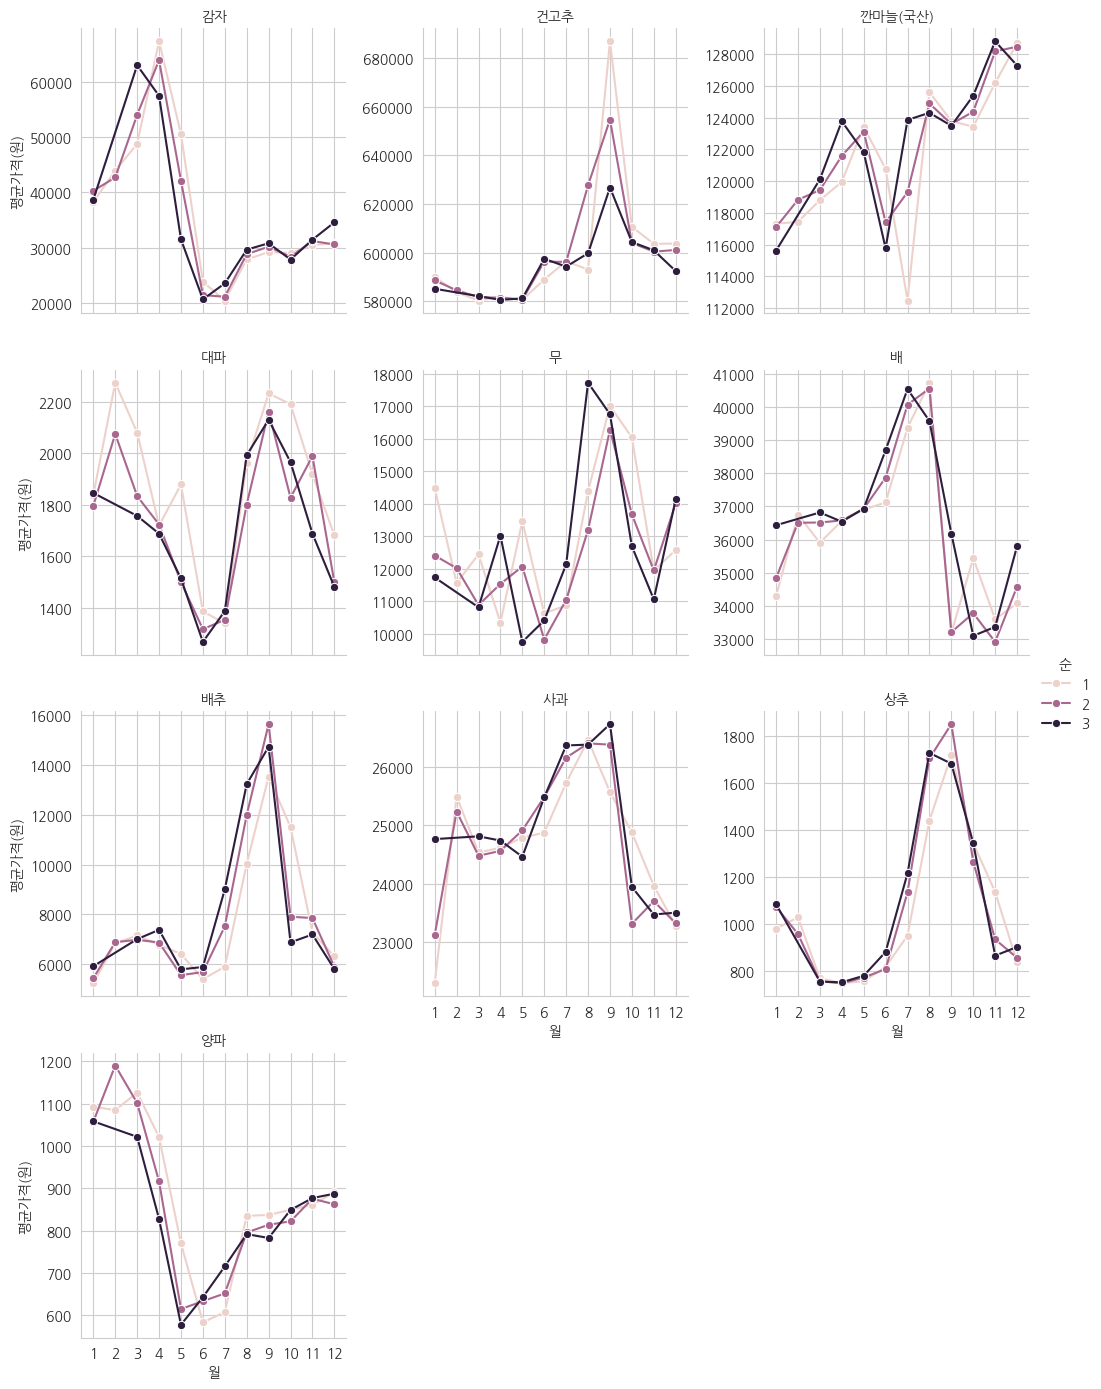

In [ ]:
# 농산물 가격의 “월별 + 순(상순/중순/하순)” 계절 패턴
soon_pattern = (
    df_time.groupby(["품목명", "month", "soon"])["평균가격(원)"]
    .mean()
    .reset_index()
)

g = sns.FacetGrid(
    soon_pattern,
    col="품목명",
    col_wrap=3,
    height=3.5,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x="month",
    y="평균가격(원)",
    hue="soon",
    marker="o"
)

g.add_legend(title="순")
g.set_axis_labels("월", "평균가격(원)")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.set_xticks(range(1, 13))
    ax.tick_params(axis="x", rotation=0)

plt.show()

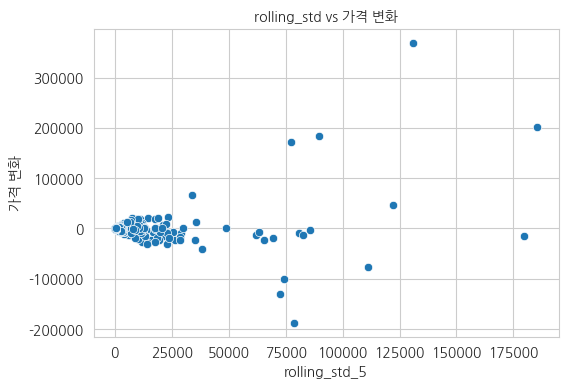

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# df_time을 사용하여 시계열 분석을 수행합니다.
# lag 및 rolling 계산이 품목별로 정확하게 이루어지도록 품목명과 날짜를 기준으로 정렬합니다.
df_time = df_time.sort_values(by=['품목명', 'date'])

# '품목명'별로 그룹화하여 '평균가격(원)'의 lag1 및 rolling_std_5를 계산합니다.
df_time['lag1'] = df_time.groupby('품목명')['평균가격(원)'].shift(1)
df_time['rolling_std_5'] = df_time.groupby('품목명')['평균가격(원)'].rolling(window=5, min_periods=1).std().reset_index(level=0, drop=True)

# 정확한 컬럼 이름을 사용하여 price_change를 계산합니다.
df_time['price_change'] = df_time['평균가격(원)'] - df_time['lag1']

plt.figure(figsize=(6,4))
sns.scatterplot(x=df_time['rolling_std_5'], y=df_time['price_change'])
plt.title("rolling_std vs 가격 변화", fontproperties=fontprop)
plt.xlabel("rolling_std_5", fontproperties=fontprop)
plt.ylabel("가격 변화", fontproperties=fontprop)
plt.show()

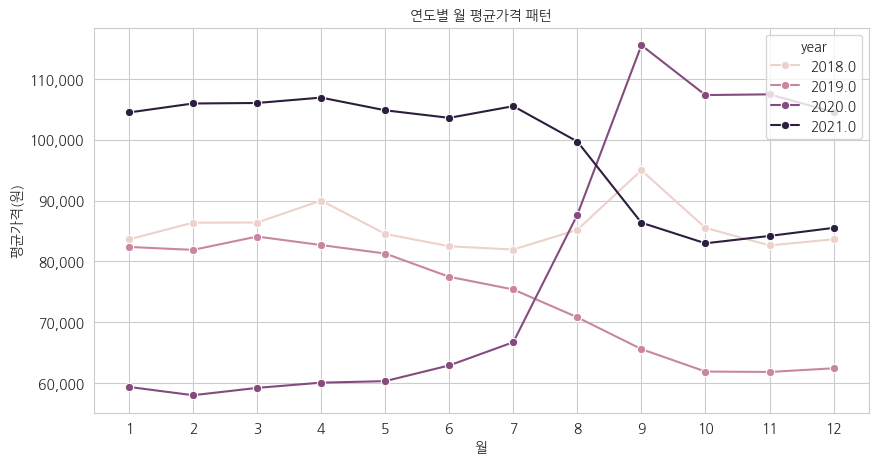

In [ ]:
import matplotlib.ticker as ticker

df_time['year'] = df_time['date'].dt.year
year_month_avg = df_time.groupby(['year', 'month'])['평균가격(원)'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=year_month_avg, x='month', y='평균가격(원)', hue='year', marker='o')

plt.title("연도별 월 평균가격 패턴", fontproperties=fontprop)
plt.xlabel("월", fontproperties=fontprop)
plt.ylabel("평균가격(원)", fontproperties=fontprop)

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.xticks(range(1, 13))
plt.legend(title='year')

plt.show()

## 파일 연결